In [38]:
# Standard libraries
import sys

#Interactive library

import plotly.express as px

# Data handling
import numpy as np
import pandas as pd

# Machine learning
import sklearn

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

##Load and adjust the data:##

In [39]:
directory_data = "../data" # Adjust the path to your data directory if necessary
movies = pd.read_csv(f"{directory_data}/raw/movies.csv")  # Adjust the path to your data directory if necessary
ratings = pd.read_csv(f"{directory_data}/raw/ratings.csv")
tags = pd.read_csv(f"{directory_data}/raw/tags.csv")

In [40]:
print(movies.head())
print(ratings.head())
print(tags.head())


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating   timestamp
0       1        1     4.0  1225734739
1       1      110     4.0  1225865086
2       1      158     4.0  1225733503
3       1      260     4.5  1225735204
4       1      356     5.0  1225735119
   userId  movieId            tag   timestamp
0      10      260   good vs evil  1430666558
1      10      260  Harrison Ford  1430666505
2      10      260         sci-fi

##structure it:##

In [41]:
print("MOVIES DATASET: ")
print(f"Shape: {movies.shape}")
print (f"Columns: {movies.columns.tolist()}")

print("\nRATINGS DATASET: ")
print(f"Shape: {ratings.shape}")
print(f"Columns: {ratings.columns.tolist()}")

print("\nTAGS DATASET: ")
print(f"Shape: {tags.shape}")
print(f"Columns: {tags.columns.tolist()}")


MOVIES DATASET: 
Shape: (86537, 3)
Columns: ['movieId', 'title', 'genres']

RATINGS DATASET: 
Shape: (33832162, 4)
Columns: ['userId', 'movieId', 'rating', 'timestamp']

TAGS DATASET: 
Shape: (2328315, 4)
Columns: ['userId', 'movieId', 'tag', 'timestamp']


userID = anonymized user
movieID = movie beeing rated
rating = rating given by user
timestamp = time when the rating was submitted

What is the interval for the scores?

In [42]:
ratings["rating"].min(), ratings["rating"].max()



(np.float64(0.5), np.float64(5.0))

##Display the data:##

In [43]:
display(movies.head())
display(ratings.head())
display(tags.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


multiple genres for one movie. Might be a way to sort how alike two mives are.

##genres: 
how do they look?

In [44]:
movies["genres"].head()


0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
Name: genres, dtype: str

they are spearated by|| and includes several per movie. 
Split them. how many categories? which are the most used? anomalies?

In [45]:
movies["genres"].str.split("|").explode().nunique()

20

In [46]:
movies["genres"].str.split("|").explode().value_counts()


genres
Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301
Western                1690
Musical                1059
Film-Noir               354
IMAX                    195
Name: count, dtype: int64

In [47]:
genre = movies["genres"].str.split("|").explode()
genre_counts = genre.value_counts()


figure = px.bar(
    x=genre_counts.index,
    y=genre_counts.values,
    labels={"x": "Genre", "y": "number of movies"},
    title="Number of movies by genre"
)

figure = px.bar(
    genre_counts.sort_values(ascending=False),
    labels={"value": "Number of movies", "index": "Genre"},
    title="Number of movies by genre"

)

figure.show()

##What is included in "no genre listed"?
explore:  
Is tehre ratings to these movies?  
what kind of movies are they?  
From which year is the movie?

**Are there any ratings?**  

In [48]:
no_genre_movies = movies[movies["genres"] == "(no genres listed)"]

ratings[ratings["movieId"].isin(no_genre_movies["movieId"])].shape

(56059, 4)

This shows 56059 ratings in the category "no genre" but not how many movies that has ratings.

In [49]:
ratings[ratings["movieId"].isin(no_genre_movies["movieId"])]["movieId"].nunique()

6521

It does not look like the category "no genre" is affected by not beeing rated.

##From which year is these movies?  
I need to split the name category to show year separately from moviename.  
I will try regex to extract the year:

In [50]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float)
movies["year"] = pd.to_numeric(movies["year"], errors="coerce")

**regex vocabulary:**
\( = left parenthesis
\d/{4} = four numbers
\) = right parenthesis

In [51]:
no_genre_movies = movies[movies["genres"] == "(no genres listed)"]
no_genre_movies["decade"] = (no_genre_movies["year"] // 10) * 10

figure = px.bar(
    x=no_genre_movies["decade"].value_counts().index,
    y=no_genre_movies["decade"].value_counts().values,
    labels={"x": "decade", "y": "number of movies"},
    title="Number of movies by decade"
)

figure = px.bar(
    no_genre_movies["decade"].value_counts().sort_index(),
    labels={"value": "Number of movies", "index": "Decade"},
    title="Number of movies by decade"
)


figure.show()


Why the drop in unrated movies in the 2020's?

In [52]:
movies_per_decade = movies["year"].value_counts().sort_index()

The raw counts of movies without genre decrease in the 2020s, but this may be due to fewer movies being present in the dataset for that decade. To account for this, the proportion of movies without genre was calculated.
occording to movielens the dataset has been latest update in 2018.

In [ ]:
combined = pd.concat([movies_per_decade, no_genre_movies["decade"].value_counts()], axis=1)
combined.columns = ["total_movies", "no_genre_movies"]
combined = combined.fillna(0)
combined["percentage_no_genre"] = (combined["no_genre_movies"] / combined["total_movies"]) * 100

c:\Users\laura\Projekt\code\git\movie_recommendation_system\.venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\laura\Projekt\code\git\movie_recommendation_system\.venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


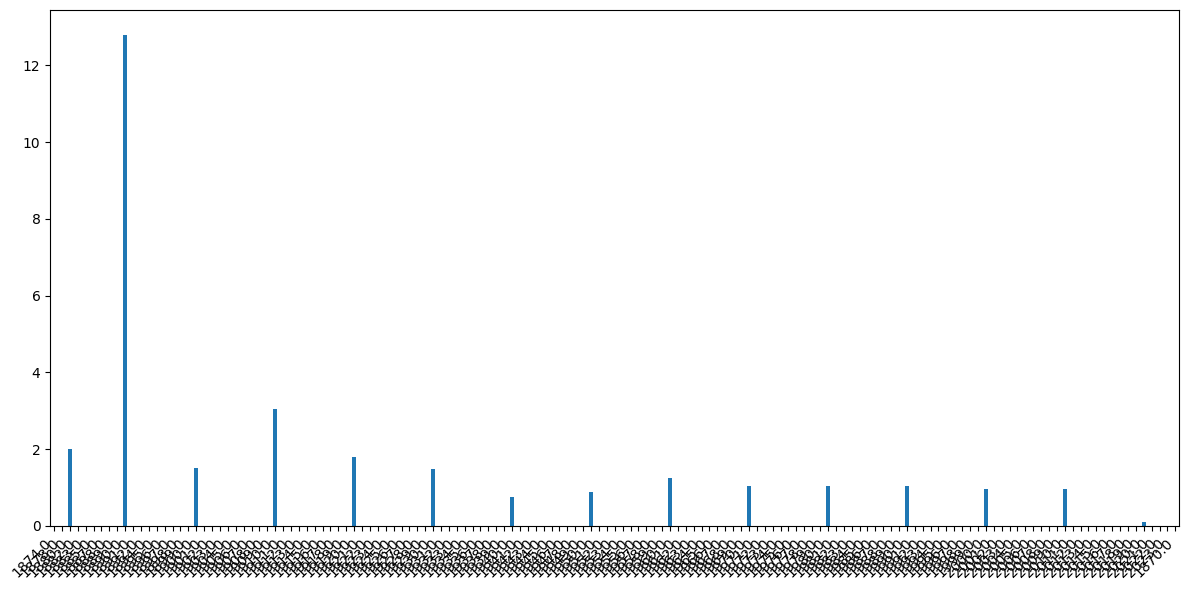

In [57]:
combined["percentage_no_genre"].plot(kind="bar", figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#next step:  
##sort this out!